# Assingment1

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import piplite
await piplite.install('seaborn')

# Part A: Model Code

## 1) Write a function to calculate and return the Euclidean distance of two vectors.

In [91]:
# Calculate the Euclidean distance between two vectors.
def euclidean_distance(v1, v2):
    return np.sqrt(np.sum((v1 - v2) ** 2))

## 2) Write a function to calculate and return the Manhattan distance of two vectors

In [52]:
# Calculate the Manhattan distance between two vectors.
def manhattan_distance(v1, v2):
    # Ensure both vectors are of the same 
    if v1.shape != v2.shape:
        raise ValueError("Vectors must be of the same length")
    return np.sum(np.abs(v1 - v2))


## 3) Write a function to calculate and return the accuracy and generalization error of two vectors.

In [53]:
# Calculate and return the accuracy and generalization error given true labels and predicted labels 
def accuracy_N_gen_error(true_labels, pred_labels):
    # Ensure both vectors are of the same length
    if true_labels.shape != pred_labels.shape:
        raise ValueError("True labels and predicted labels must be of the same length")
    
    # Calculate the number of correctly predicted labels
    correct_predictions = np.sum(true_labels == pred_labels)
    
    # Calculate accuracy and generalization error
    accuracy = correct_predictions / true_labels.size
    generalization_error = 1 - accuracy
    return accuracy, generalization_error

# TESTING  Define the true and predicted labels, then test func
true_labels = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
predicted_labels = np.array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

accuracy, gen_error = accuracy_N_gen_error(true_labels, predicted_labels)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Generalization Error: {gen_error*100:.2f}%")


Accuracy: 60.00%
Generalization Error: 40.00%


## 4) Write three functions to compute: precision, recall and F1 score

### 4.1 function to compute precision

In [54]:
""" Compute precision from the confusion matrix.
  - confusion_matrix: A 2x2 NumPy array representing the confusion matrix.
"""
def get_precision(confusion_matrix):
    #TP -- True Positives  ; FP -- False Positives 
    TP = confusion_matrix[1, 1]
    FP = confusion_matrix[0, 1]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    return precision

### 4.2 function to comute recall

In [55]:
# Compute the ratio of TP to the actual positives (TP + FN).
def get_recall(confusion_matrix):
    #TP -- True Positives  ; FN -- False Negative 
    TP = confusion_matrix[1, 1]
    FN = confusion_matrix[1, 0]
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    return recall

### 4.3 function to compute the F1 score

In [56]:
# Compute F1 score 
def get_f1_score(confusion_matrix):
    precision = get_precision(confusion_matrix)
    recall = get_recall(confusion_matrix)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1_score

## 5) Write a function to compute the confusion matrix of two vector

In [57]:
"""
    True Positives (TP): Correctly predicted positive observations.
    True Negatives (TN): Correctly predicted negative observations.
    False Positives (FP): Incorrectly predicted positive observations (a.k.a. Type I error).
    False Negatives (FN): Incorrectly predicted negative observations (a.k.a. Type II error).
    Returns A 2x2 NumPy array representing confusion matrix with the format: [[TN, FP],[FN, TP]]
"""
def get_confusion_matrix(true_labels, predicted_labels):
    # Initialize the confusion matrix
    confusion_matrix = np.zeros((2, 2), dtype=int)
    
    # Calculate the values for the confusion matrix
    confusion_matrix[0, 0] = np.sum((predicted_labels == 0) & (true_labels == 0)) # True Negatives
    confusion_matrix[1, 0] = np.sum((predicted_labels == 0) & (true_labels == 1)) # False Negatives
    confusion_matrix[1, 1] = np.sum((predicted_labels == 1) & (true_labels == 1)) # True Positives
    confusion_matrix[0, 1] = np.sum((predicted_labels == 1) & (true_labels == 0)) # False Positives
    
    return confusion_matrix

### Test for (4) and (5)

In [58]:
# Example true and predicted labels
true_labels = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
predicted_labels = np.array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])
# Compute the confusion matrix
conf_matrix = get_confusion_matrix(true_labels, predicted_labels)
# Calculate precision, recall, and F1 score
precision = get_precision(conf_matrix)
recall = get_recall(conf_matrix)
f1_score = get_f1_score(conf_matrix)

print(f"Confusion Matrix:{conf_matrix}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

Confusion Matrix:[[3 2]
 [2 3]]
Precision: 0.60
Recall: 0.60
F1 Score: 0.60


## 6) Write a function to generate the Receiver Operating Characteristic (ROC) curve

In [59]:
# Generating the ROC curve by calculating the True Positive Rate(TPR) and False Positive Rate(FPR) 
# at various threshold settings 
# predicted_probs： predicted probabilities
def generate_roc_curve(true_labels, predicted_probs):
    # Ensure predicted_probs are in a numpy array
    predicted_probs = np.array(predicted_probs)
    
    # Sort the predicted probabilities and corresponding true labels
    indices = np.argsort(predicted_probs)
    sorted_probs = predicted_probs[indices]
    sorted_labels = true_labels[indices]
    
    # Create arrays to store True Positive Rate(TPR) and False Positive Rate (FPR)
    tprs, fprs = [],[]
    
    # Create an array of thresholds from the sorted predicted probabilities
    thresholds = np.unique(sorted_probs)
    
    # Add a threshold that is larger than the maximum predicted probability to 
    # capture the case where all predictions are negative
    thresholds = np.append(thresholds, thresholds[-1] + 1)
    
    # Calculate TPR and FPR for each threshold
    for threshold in thresholds:
        # Make predictions based on the current threshold
        predictions = (sorted_probs >= threshold).astype(int)
        
        # True positives, false positives, true negatives, false negatives
        TP = np.sum((predictions == 1) & (sorted_labels == 1))
        FP = np.sum((predictions == 1) & (sorted_labels == 0))
        TN = np.sum((predictions == 0) & (sorted_labels == 0))
        FN = np.sum((predictions == 0) & (sorted_labels == 1))
        
        # Calculate TPR and FPR
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        # Append the TPR and FPR to the arrays
        tprs.append(TPR)
        fprs.append(FPR)
    
    return np.array(fprs), np.array(tprs), thresholds


## 7) Write a function to compute area under curve (AUC) for the ROC curve.

In [60]:
# Calculate the Area Under the Curve (AUC) for the ROC curve
def calculate_auc(fpr, tpr):
    # Sort by increasing FPRs
    sorted_indices = np.argsort(fprs)
    sorted_fprs = fprs[sorted_indices]
    sorted_tprs = tprs[sorted_indices]
    
    # Calculate the area using the trapezoidal rule
    auc = np.trapz(sorted_tprs, sorted_fprs)
    return auc

### Test for (6) and (7)

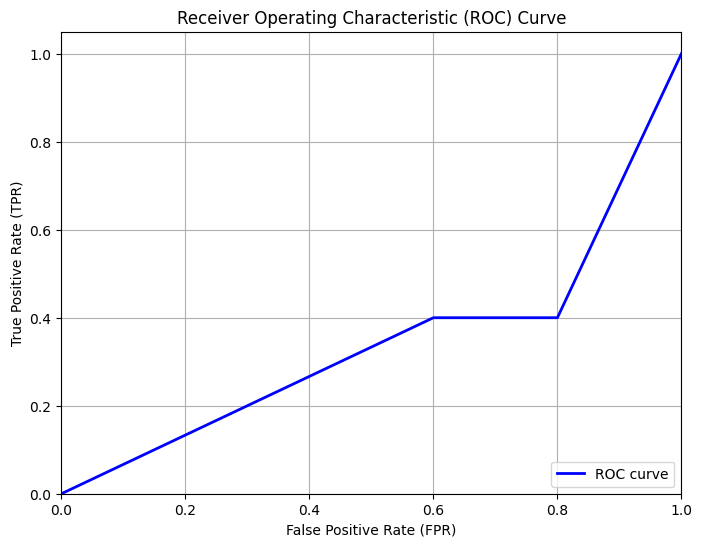

AUC: 0.340


In [61]:
# Example true labels and predicted probabilities
true_labels = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
predicted_probs = np.array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0.4])

# Generate ROC curve data
fprs, tprs, thresholds = generate_roc_curve(true_labels, predicted_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, color='blue', lw=2, label='ROC curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

auc = calculate_auc(fprs, tprs)
print(f"AUC: {auc:.3f}")

## 8) Precision-Recall curve

In [62]:
#Generate precision and recall for various thresholds to plot the precision-recall curve.
def generate_precision_recall(true_labels, predicted_probs):
    # Create an array of thresholds from the predicted probabilities
    thresholds = np.unique(predicted_probs)
    # Initialize lists to store precision and recall values
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        predicted_labels = (predicted_probs >= threshold).astype(int)
        cm = get_confusion_matrix(true_labels, predicted_labels)
        TP = cm[1, 1]
        FP = cm[0, 1]
        FN = cm[1, 0]
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.array(precisions), np.array(recalls), thresholds

### Test Case

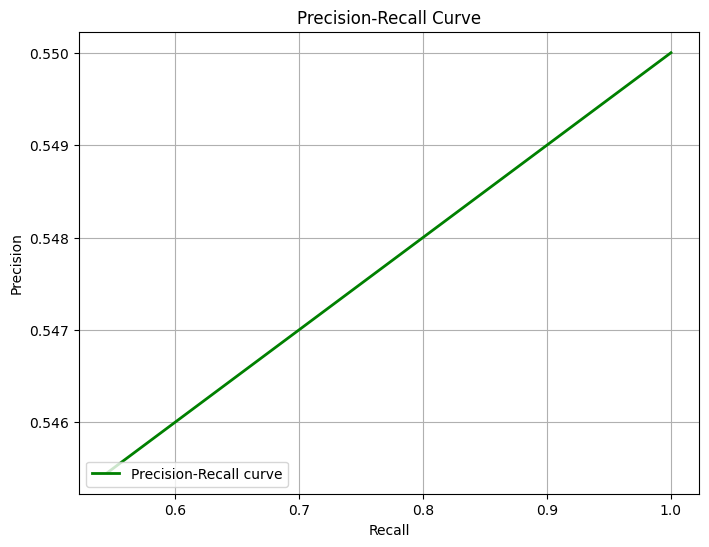

In [63]:
# Example true labels and predicted probabilities for a characteristic precision-recall curve
true_labels = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1])
predicted_probs = np.array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1])

# Generate precision and recall values
precisions_curved, recalls_curved, thresholds_curved = generate_precision_recall(true_labels, predicted_probs)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recalls_curved, precisions_curved, color='green', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

## 9) KNN_Classifier class

In [98]:
class KNN_Classifier:
    # Initialize placeholder variables for the classifier's settings
    def __init__(self):
        self.X_train = None # Training data features
        self.Y_train = None # Training data labels
        self.n_neighbors = None # Number of neighbors to consider
        self.weights = None # Weighting method ('uniform' or 'distance')
        self.distance_type = None # Distance metric ('euclidean' or 'manhattan')

    # Store the training data, labels, number of neighbors, weight function, and distance type.
    def fit(self, X, Y, n_neighbors=5, weights='uniform', distance='euclidean'):
        self.X_train = X
        self.Y_train = Y
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.distance_type = distance
        
    # Predict the class labels for provided samples based on the k-nearest neighbors.
    def predict(self, X):
        distances = self._compute_distances(X)
        
        # Identify the indices of the n_neighbors nearest neighbors for each test sample
        nearest_indices = np.argsort(distances)[:self.n_neighbors]
        # Extract the labels of the nearest neighbors
        nearest_labels = self.Y_train[nearest_indices]
        
        # Initialize an empty list to store predictions for each test sample
        predictions = []
        
        # Loop over each set of nearest labels to determine the predicted label for each test sample
        for i in range(nearest_labels.shape[0]):
            if self.weights == 'uniform':
                values, counts = np.unique(nearest_labels[i], return_counts=True)
                prediction = values[np.argmax(counts)]
            elif self.weights == 'distance':
                unique_labels = np.unique(nearest_labels[i])
                label_weights = {label: 0 for label in unique_labels}
                for label in nearest_labels[i]:
                    label_weights[label] += 1 / (distances[i][nearest_labels[i] == label].sum() + 1e-5)
                prediction = max(label_weights, key=label_weights.get)
            predictions.append(prediction)
        
        return np.array(predictions)

    #Compute distances between test samples and all training samples.
    def _compute_distances(self, X):
        if self.distance_type == 'euclidean':
            dist_func = euclidean_distance
        elif self.distance_type == 'manhattan':
            dist_func = manhattan_distance
        else:
            raise ValueError("Only 'euclidean' and 'manhattan' are supported.")
            
        # Calculate distances from each test sample to all training samples by using broadcasting for efficiency
        distances = np.array([dist_func(X_sample, self.X_train) for X_sample in X])
        return distances


# Part B: Data Processing

## 10) Read in the winequality-white.csv file as a Pandas data frame

In [65]:
# Read in the 'winequality-white.csv' file as a Pandas data frame
wine_data = pd.read_csv('winequality-white.csv', sep=';')

wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


## 11) Binarizing Wine Quality for Classification

In [66]:
# Binarizing wine quality based quality by replacing quality > 5 with 1 and quality <=5 with 0
# where 1 represents 'good' and 0 represents 'bad'
wine_data['quality'] = wine_data['quality'].apply(lambda x: 1 if x > 5 else 0)
wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


## 12) Mean, Standard Deviation, and Quartiles of each variables 

In [67]:
# Summarize variables in the dataset
summary_statistics = wine_data.describe().round(4).loc[['mean', 'std', '25%', '50%', '75%']]
# Display the summary statistics
summary_statistics

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,6.8548,0.2782,0.3342,6.3914,0.0458,35.3081,138.3607,0.9940,3.1883,0.4898,10.5143,0.6652
std,0.8439,0.1008,0.1210,5.0721,0.0218,17.0071,42.4981,0.0030,0.1510,0.1141,1.2306,0.4720
25%,6.3000,0.2100,0.2700,1.7000,0.0360,23.0000,108.0000,0.9917,3.0900,0.4100,9.5000,0.0000
50%,6.8000,0.2600,0.3200,5.2000,0.0430,34.0000,134.0000,0.9937,3.1800,0.4700,10.4000,1.0000
75%,7.3000,0.3200,0.3900,9.9000,0.0500,46.0000,167.0000,0.9961,3.2800,0.5500,11.4000,1.0000


## 13) Shuffle rows of wine data

In [102]:
# Shuffle the wind data 
# The drop=True parameter is used to avoid the old index being added as a column.
shuffled_wine = wine_data.sample(frac=1).reset_index(drop=True)
shuffled_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.0,0.67,0.07,1.2,0.060,9.0,108.0,0.99310,3.11,0.35,8.7,0
1,6.4,0.32,0.23,16.2,0.055,36.0,176.0,0.99860,3.26,0.54,9.1,0
2,6.8,0.41,0.30,8.8,0.045,28.0,131.0,0.99530,3.12,0.59,9.9,0
3,6.4,0.23,0.32,1.9,0.038,40.0,118.0,0.99074,3.32,0.53,11.8,1
4,5.7,0.36,0.21,6.7,0.038,51.0,166.0,0.99410,3.29,0.63,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.9,0.20,0.30,4.7,0.041,40.0,148.0,0.99320,3.16,0.35,10.2,1
4894,7.3,0.34,0.21,3.2,0.050,14.0,136.0,0.99360,3.25,0.44,10.2,0
4895,5.9,0.29,0.33,7.4,0.037,58.0,205.0,0.99495,3.26,0.41,9.6,0
4896,6.4,0.17,0.27,6.7,0.036,88.0,223.0,0.99480,3.28,0.35,10.2,1


## 14&15) Pairplots, corrolation, and drop the redundant features

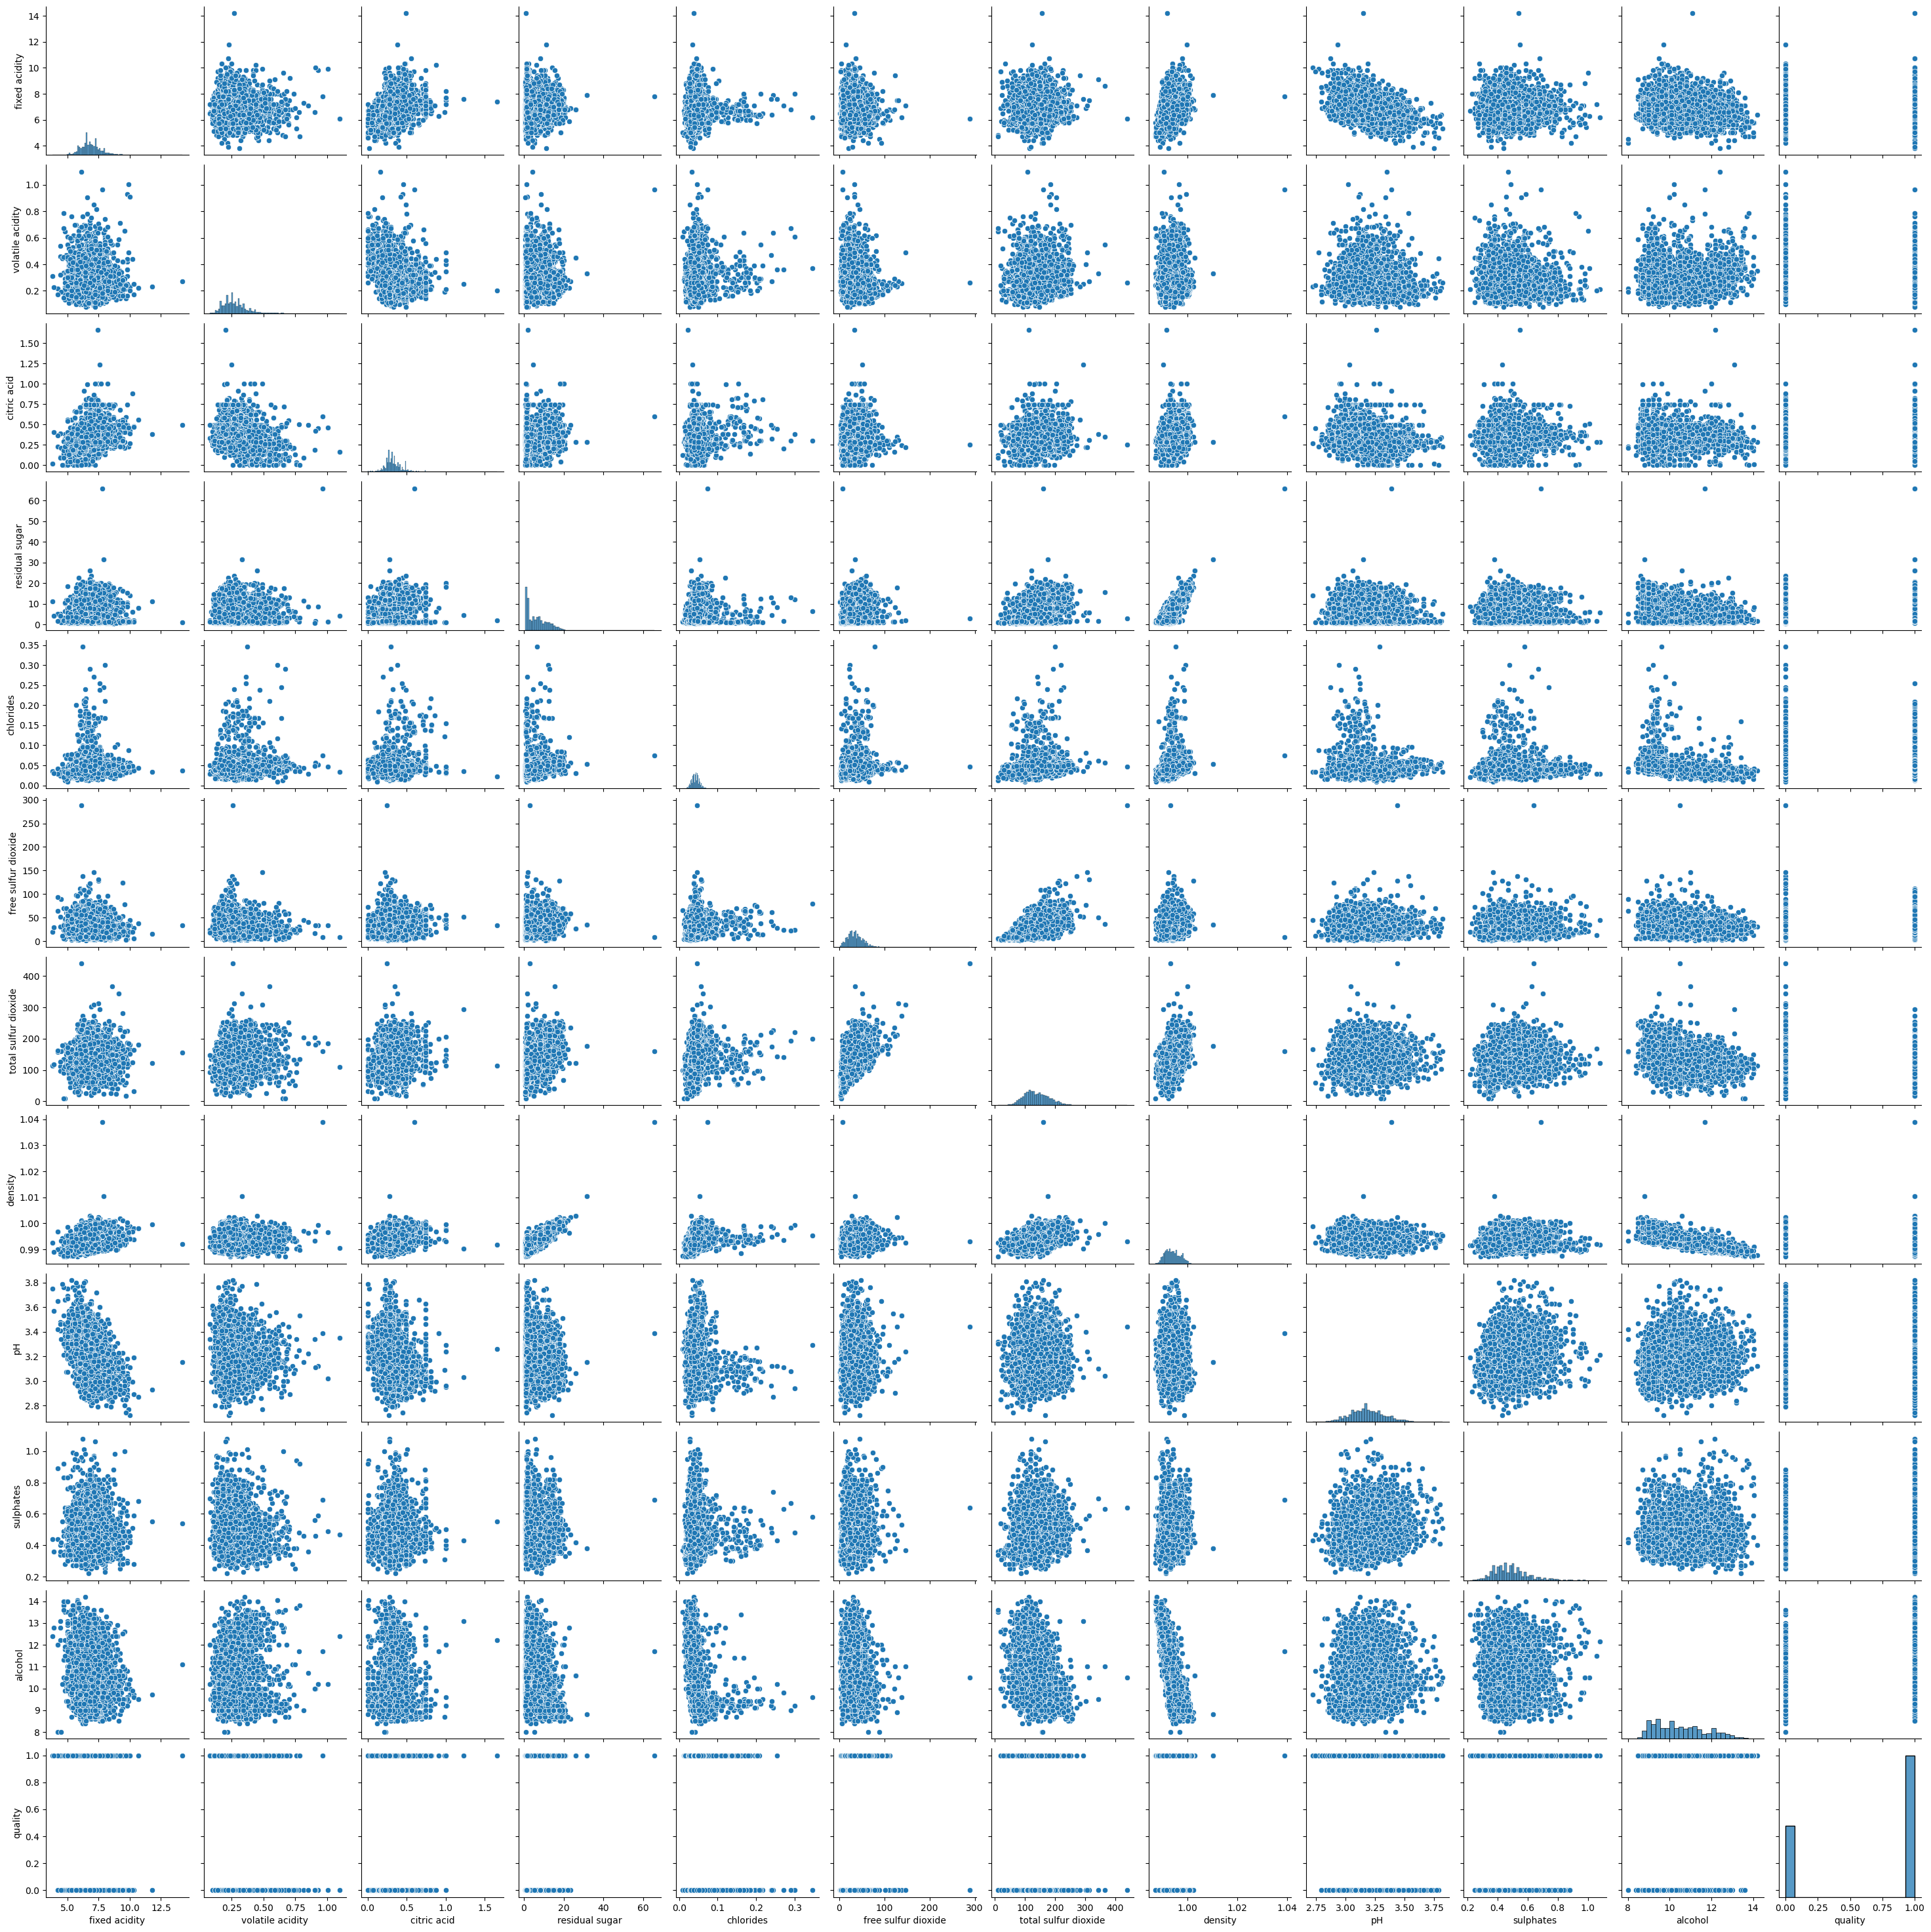

In [69]:
# Plot the corrolation between all of the given features
import seaborn as sns
sns.pairplot(shuffled_wine)
plt.show()

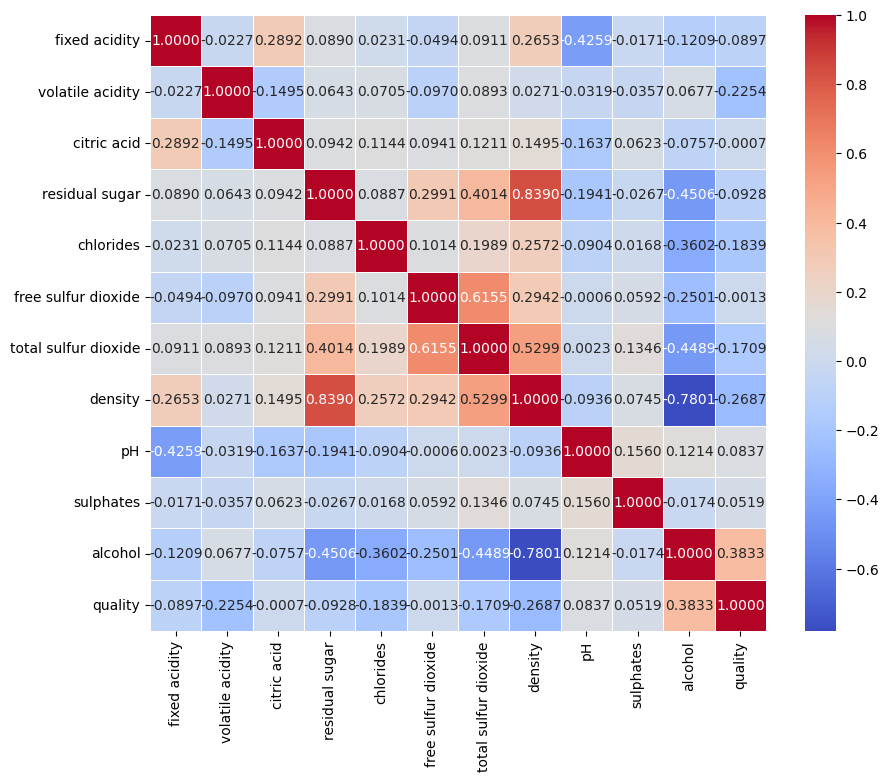

In [70]:
# Compute the correlation matrix
corr = shuffled_wine.corr()

# Generate a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".4f", cmap='coolwarm', square=True, linewidths=.5)
plt.show()

In [114]:
# Based on the correlation matrix. 'residual sugar' and 'density' show a very high positive correlation (0.838966). 
# One of them is suggested to drop from the data. 
# In my case, 'residual sugar' is determined to drop from the DataFrame
wine_data_reduced = shuffled_wine.drop('residual sugar', axis=1)
wine_data_reduced

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.0,0.67,0.07,0.060,9.0,108.0,0.99310,3.11,0.35,8.7,0
1,6.4,0.32,0.23,0.055,36.0,176.0,0.99860,3.26,0.54,9.1,0
2,6.8,0.41,0.30,0.045,28.0,131.0,0.99530,3.12,0.59,9.9,0
3,6.4,0.23,0.32,0.038,40.0,118.0,0.99074,3.32,0.53,11.8,1
4,5.7,0.36,0.21,0.038,51.0,166.0,0.99410,3.29,0.63,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.9,0.20,0.30,0.041,40.0,148.0,0.99320,3.16,0.35,10.2,1
4894,7.3,0.34,0.21,0.050,14.0,136.0,0.99360,3.25,0.44,10.2,0
4895,5.9,0.29,0.33,0.037,58.0,205.0,0.99495,3.26,0.41,9.6,0
4896,6.4,0.17,0.27,0.036,88.0,223.0,0.99480,3.28,0.35,10.2,1


## 16) Write a function “partition” to split  data into training and test set

In [112]:
# Partition the dataset into training and test sets based on the specified partition size.
def partition(feature_matrix, target_vector, t):
    # Calculate the number of samples
    num_samples = feature_matrix.shape[0]
    
    # Shuffle the dataset to ensure that the training and test sets are random subsets of the data.
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    feature_matrix = feature_matrix[indices]
    target_vector = target_vector[indices]
    
    # Determine the split index
    split_index = int(num_samples * (1 - t))
    
    # Split the feature matrix and target vector
    feature_train = feature_matrix[:split_index]
    feature_test = feature_matrix[split_index:]
    target_train = target_vector[:split_index]
    target_test = target_vector[split_index:]
    
    return feature_train, feature_test, target_train, target_test

## 17) Run your KNN_Classifier model on the training dataset 

### a) Running KNN_Classifier Without Standardization

In [115]:
# Separate the features and the target variable
features = wine_data_reduced.loc[:, wine_data_reduced.columns[:-1]]
target = wine_data_reduced.loc[:, wine_data_reduced.columns[:-1]]

# Partition the data with a specified split, 20% test set (t=0.2)
X_train, X_test, y_train, y_test = partition(features, target, 0.2)

# Initialize the KNN classifier with n_neighbors=5 using Euclidean distance and uniform weights
knn = KNN_Classifier()
knn.fit(X_train, y_train, n_neighbors=5, weights='uniform', distance='euclidean')

# Predict the labels for the test set
y_pred = knn.predict(X_test)

# Calculate the confusion matrix based on true and predicted labels
conf_matrix = get_confusion_matrix(y_test, y_pred)

# Calculate the F1 score using the confusion matrix
f1_score = get_f1_score(conf_matrix)

# Use the provided accuracy and generalization error function to calculate accuracy
accuracy, generalization_error = accuracy_N_gen_error(y_test, y_pred)

# Print the accuracy and F1 score for unscaled data
print(f"Unscaled Data - Accuracy: {accuracy}, F1 Score: {f1_score}")


<class 'KeyError'>: "None of [Int64Index([1077, 2779, 4138,  102,  695, 2472, 3880, 3088,  276, 4414,\n            ...\n            3820, 1754, 4395, 4398,  546,  159, 3853,  109, 1016, 4465],\n           dtype='int64', length=4898)] are in the [columns]"